<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%;">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologias Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Linea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibague-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingenieria</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingenieria de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab -- 02 Preprocessing & Cropping</div>

# 02 -- Preprocessing & YOLO Cropping

Este notebook implementa el preprocesamiento completo del dataset usando `src/data/cropping.py`.

### Pipeline por imagen

```
imagen raw
    |
    v
[1] Detectar con YOLOv8 (yolov8n.pt)
    |
    v
[2] Tomar la deteccion de mayor confianza (clase bird)
    |
    v
[3] Filtrar: confianza >= min_confidence (0.5)        --rechazo: LOW_CONFIDENCE
    |
    v
[4] Aplicar margen dinamico (margin_ratio = 20%)
    |
    v
[5] Clipear bbox a limites de la imagen               --rechazo: BBOX_CLIPPED_EMPTY
    |
    v
[6] Filtrar: area_bbox / area_imagen >= 0.05          --rechazo: BBOX_TOO_SMALL
    |
    v
[7] Recortar la region valida (sin padding)
    |
    v
[8] Resize manteniendo aspect ratio (lado menor = 224)
    |
    v
[9] Center crop 224x224                               --rechazo: IMAGE_TOO_SMALL
    |
    v
  imagen procesada (224x224, sin bordes artificiales)
```

> **Regla fundamental:** en ningun paso se introduce padding. Si el bbox queda
> fuera de la imagen tras el margen, se clipea. Si la region resultante es muy
> pequenia, la imagen se descarta.


## 1. Entorno y configuracion

In [1]:
import sys
from pathlib import Path
from collections import defaultdict
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset.yaml"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print("Configuracion de preprocesamiento:")
print(f"  image_size           : {config['image_size']} px")
print(f"  min_confidence       : {config['min_confidence']}")
print(f"  min_bbox_area_ratio  : {config['min_bbox_area_ratio']}")
print(f"  margin_ratio         : {config['margin_ratio']}")


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


Configuracion de preprocesamiento:
  image_size           : 224 px
  min_confidence       : 0.5
  min_bbox_area_ratio  : 0.05
  margin_ratio         : 0.2


## 2. Inicializar BirdCropper

`BirdCropper` carga YOLOv8n la primera vez que procesa una imagen
(descarga automatica ~6 MB si no existe en cache).


In [3]:
from src.utils.cropping import BirdCropper, RejectionReason, process_class_directory

cropper = BirdCropper.from_config(str(CONFIG_PATH))

# Forzar la carga del modelo ahora para ver el mensaje de descarga aqui
_ = cropper.model
print("Modelo YOLO listo.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/walter/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Modelo YOLO listo.


## 3. Prueba unitaria -- una sola imagen

Antes de procesar todo el dataset, verificamos el pipeline con una imagen individual.
Esto muestra visualmente cada paso: bbox original, bbox con margen, bbox clipeado y crop final.


In [4]:
RAW_DIR = PROJECT_ROOT / config["raw_data_path"]

# Tomar la primera imagen disponible del dataset
sample_path = next(
    (f for cls_dir in sorted(RAW_DIR.iterdir()) if cls_dir.is_dir()
     for f in sorted(cls_dir.iterdir())
     if f.suffix.lower() in {".jpg", ".jpeg", ".png"}),
    None
)

if sample_path is None:
    print("No se encontraron imagenes en data/raw/. Ejecuta 01_data_ingestion primero.")
else:
    print(f"Imagen de prueba: {sample_path.relative_to(PROJECT_ROOT)}")
    result = cropper.crop(sample_path)
    print(f"Resultado: {'ACEPTADA' if result.success else 'RECHAZADA'}")
    if result.confidence is not None:
        print(f"  Confianza YOLO : {result.confidence:.3f}")
    if result.bbox_clipped:
        x1,y1,x2,y2 = [int(v) for v in result.bbox_clipped]
        print(f"  Bbox clipeado  : ({x1},{y1}) -> ({x2},{y2})")
    if not result.success:
        print(f"  Razon de rechazo: {result.rejection_reason}")


Imagen de prueba: data/raw/ardea-alba/ardea-alba_008cc887a4.jpg
Resultado: ACEPTADA
  Confianza YOLO : 0.861
  Bbox clipeado  : (99,40) -> (275,183)


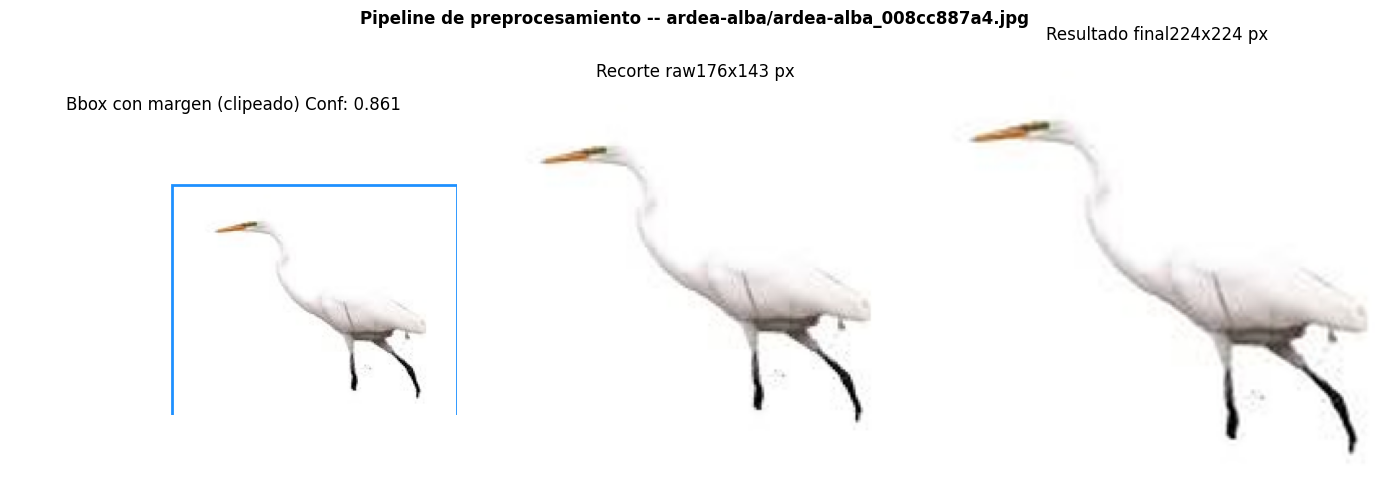

In [6]:
# Visualizacion paso a paso de la imagen de prueba
if sample_path and result.success:
    img_orig = Image.open(sample_path).convert("RGB")
    W, H = img_orig.size

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f"Pipeline de preprocesamiento -- {sample_path.parent.name}/{sample_path.name}",
                 fontsize=12, fontweight="bold")

    # Panel 1: imagen original + bbox con margen (antes del clip)
    ax = axes[0]
    ax.imshow(img_orig)
    if result.bbox_original:
        ex1,ey1,ex2,ey2 = result.bbox_original
        # bbox clipeado en azul
        cx1,cy1,cx2,cy2 = result.bbox_clipped
        rect_clip = plt.Rectangle((cx1,cy1), cx2-cx1, cy2-cy1,
                                   edgecolor="dodgerblue", facecolor="none", lw=2)
        ax.add_patch(rect_clip)
        ax.set_title(f"Bbox con margen (clipeado) Conf: {result.confidence:.3f}")
    else:
        ax.set_title("Sin deteccion")
    ax.axis("off")

    # Panel 2: recorte antes del resize
    ax = axes[1]
    if result.bbox_clipped:
        cx1,cy1,cx2,cy2 = [int(v) for v in result.bbox_clipped]
        patch = img_orig.crop((cx1,cy1,cx2,cy2))
        ax.imshow(patch)
        ax.set_title(f"Recorte raw{patch.size[0]}x{patch.size[1]} px")
    ax.axis("off")

    # Panel 3: resultado final 224x224
    ax = axes[2]
    ax.imshow(result.image)
    ax.set_title(f"Resultado final{result.image.size[0]}x{result.image.size[1]} px")
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "logs" / "02_sample_pipeline.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4. Procesar el dataset completo

Iteramos sobre cada carpeta de clase en `data/raw/` y guardamos los recortes
en `data/processed/`. Se acumula un log completo de rechazos con la razon exacta.


In [7]:
PROCESSED_DIR = PROJECT_ROOT / config["processed_data_path"]
IMAGE_EXTS    = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# Acumuladores globales
global_accepted  = 0
global_rejected  = []          # lista de dicts {path, class, reason, conf}
stats_per_class  = {}          # {class_name: {accepted, rejected, total}}

class_dirs = sorted([d for d in RAW_DIR.iterdir() if d.is_dir()])
print(f"Clases a procesar: {len(class_dirs)}")
print()

for cls_dir in class_dirs:
    out_cls = PROCESSED_DIR / cls_dir.name
    stats   = process_class_directory(cls_dir, out_cls, cropper, IMAGE_EXTS)

    global_accepted += stats["accepted"]
    for rej in stats["rejected"]:
        global_rejected.append({
            "path":   rej["path"],
            "class":  cls_dir.name,
            "reason": rej["reason"],
            "conf":   rej["conf"],
        })

    stats_per_class[cls_dir.name] = stats
    pct = stats["accepted"] / stats["total"] * 100 if stats["total"] else 0
    print(f"  {cls_dir.name:<35}  "
          f"{stats['accepted']:>4}/{stats['total']:<4} aceptadas  "
          f"({pct:.0f}%)  rechazadas: {len(stats['rejected'])}")

total_processed = global_accepted + len(global_rejected)
print()
print(f"TOTAL  aceptadas : {global_accepted} / {total_processed}")
print(f"TOTAL  rechazadas: {len(global_rejected)}")


Clases a procesar: 16

  ardea-alba                            199/251  aceptadas  (79%)  rechazadas: 52
  atlapetes-latinuchus                  226/277  aceptadas  (82%)  rechazadas: 51
  butorides-striata                     222/266  aceptadas  (83%)  rechazadas: 44
  chlorochrysa-nitidissima              272/303  aceptadas  (90%)  rechazadas: 31
  colibri-coruscans                     226/291  aceptadas  (78%)  rechazadas: 65
  common-gallinule                      203/307  aceptadas  (66%)  rechazadas: 104
  metallura-tyrianthina                 234/291  aceptadas  (80%)  rechazadas: 57
  momotus-aequatorialis                 366/463  aceptadas  (79%)  rechazadas: 97
  phimosus-infuscatus                   263/313  aceptadas  (84%)  rechazadas: 50
  piaya-cayana                          194/346  aceptadas  (56%)  rechazadas: 152
  pitangus-sulphuratus                  207/240  aceptadas  (86%)  rechazadas: 33
  ramphastos-ambiguus                   153/329  aceptadas  (47%)  rechaz

## 5. Resumen de rechazos por razon

Agrupamos todos los rechazos por tipo para entender cuales son los problemas
mas frecuentes en el dataset.


In [8]:
from collections import Counter

reason_counts = Counter(r["reason"] for r in global_rejected)

REASON_LABELS = {
    RejectionReason.NO_DETECTION:       "Sin deteccion YOLO",
    RejectionReason.LOW_CONFIDENCE:     "Confianza baja",
    RejectionReason.BBOX_CLIPPED_EMPTY: "Bbox vacio tras clip",
    RejectionReason.BBOX_TOO_SMALL:     "Area insuficiente",
    RejectionReason.IMAGE_TOO_SMALL:    "Imagen muy pequenia",
    RejectionReason.LOAD_ERROR:         "Error al cargar",
}

print(f"{'Razon de rechazo':<35} {'Casos':>7}  {'% del total':>11}")
print("-" * 57)
for reason, count in reason_counts.most_common():
    label = REASON_LABELS.get(reason, reason)
    pct   = count / len(global_rejected) * 100 if global_rejected else 0
    print(f"{label:<35} {count:>7}  {pct:>10.1f}%")
print("-" * 57)
print(f"{'TOTAL':<35} {len(global_rejected):>7}")


Razon de rechazo                      Casos  % del total
---------------------------------------------------------
Confianza baja                          487        48.1%
Sin deteccion YOLO                      483        47.7%
Area insuficiente                        43         4.2%
---------------------------------------------------------
TOTAL                                  1013


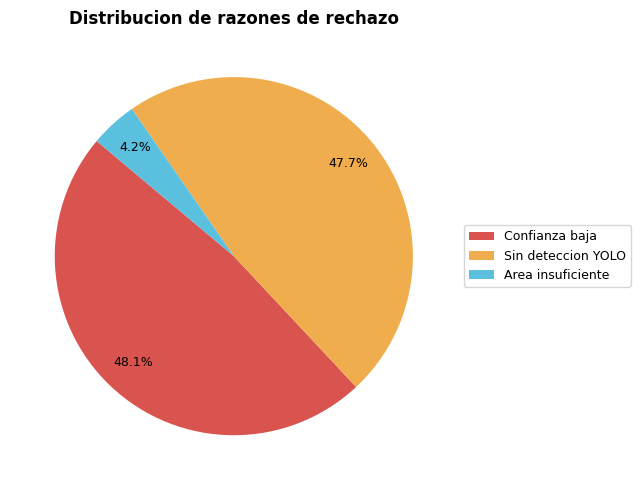

In [9]:
# Grafica de torta de razones de rechazo
if reason_counts:
    labels = [REASON_LABELS.get(r, r) for r in reason_counts.keys()]
    values = list(reason_counts.values())
    palette = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c", "#9b59b6", "#e67e22"]

    fig, ax = plt.subplots(figsize=(8, 5))
    wedges, texts, autotexts = ax.pie(
        values, labels=None, autopct="%1.1f%%",
        colors=palette[:len(values)], startangle=140,
        pctdistance=0.82
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax.legend(wedges, labels, loc="center left",
              bbox_to_anchor=(1, 0.5), fontsize=9)
    ax.set_title("Distribucion de razones de rechazo", fontweight="bold")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "logs" / "02_rejection_reasons.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Sin rechazos -- todas las imagenes fueron aceptadas.")


## 6. Tasa de rechazo por clase

Clases con alta tasa de rechazo pueden indicar problemas especificos:
- Fotos del ave muy lejanas (deteccion pequenia)
- Fondos complejos que confunden a YOLO
- Imagenes de baja resolucion


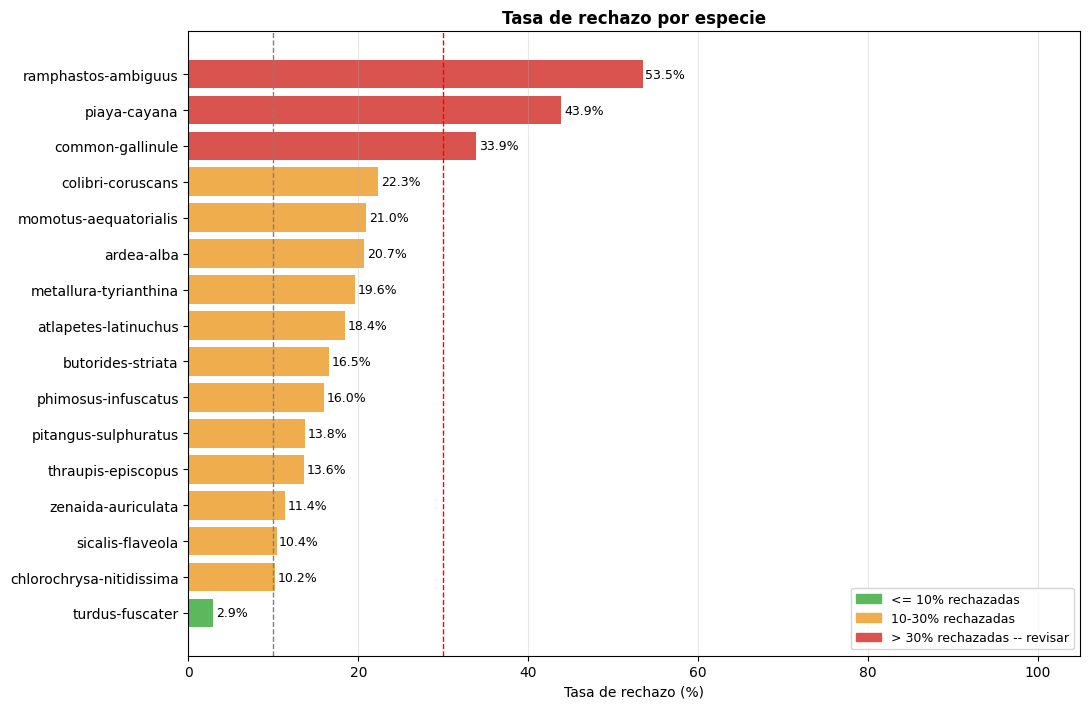

In [10]:
class_names    = list(stats_per_class.keys())
reject_rates   = [
    len(stats_per_class[c]["rejected"]) / stats_per_class[c]["total"] * 100
    if stats_per_class[c]["total"] > 0 else 0
    for c in class_names
]

sorted_pairs = sorted(zip(reject_rates, class_names), reverse=True)
sorted_rates = [p[0] for p in sorted_pairs]
sorted_names = [p[1] for p in sorted_pairs]

bar_colors = ["#d9534f" if r > 30 else "#f0ad4e" if r > 10 else "#5cb85c"
              for r in sorted_rates]

fig, ax = plt.subplots(figsize=(11, max(5, len(class_names) * 0.45)))
bars = ax.barh(sorted_names[::-1], sorted_rates[::-1], color=bar_colors[::-1])
ax.axvline(x=10, color="gray", linestyle="--", linewidth=1, label="Umbral 10%")
ax.axvline(x=30, color="red",  linestyle="--", linewidth=1, label="Umbral 30%")
for bar, val in zip(bars, sorted_rates[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Tasa de rechazo (%)")
ax.set_title("Tasa de rechazo por especie", fontweight="bold")
ax.set_xlim(0, 105)
patches = [
    mpatches.Patch(color="#5cb85c", label="<= 10% rechazadas"),
    mpatches.Patch(color="#f0ad4e", label="10-30% rechazadas"),
    mpatches.Patch(color="#d9534f", label="> 30% rechazadas -- revisar"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "02_rejection_per_class.png",
            dpi=150, bbox_inches="tight")
plt.show()


## 7. Galeria de imagenes rechazadas

Mostramos una muestra visual de las imagenes rechazadas agrupadas por razon.
Esto permite auditar visualmente si los umbrales del pipeline son correctos
o si necesitan ajustarse.


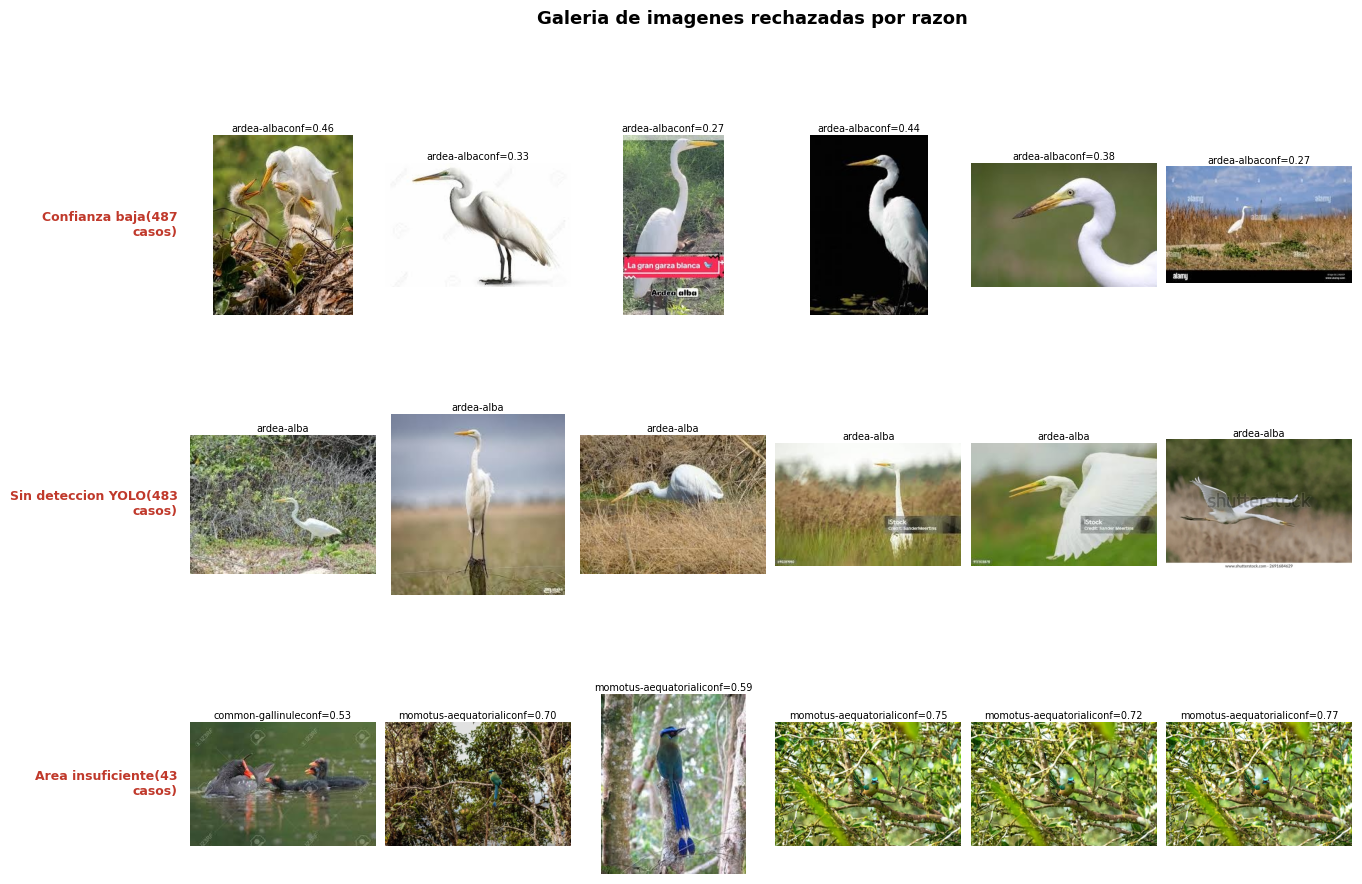

Galeria guardada en logs/02_rejected_gallery.png


In [13]:
def show_rejected_gallery(rejected_list: list, max_per_reason: int = 6):
    """
    Muestra una galeria de imagenes rechazadas agrupadas por razon.
    Cada fila es una razon de rechazo diferente.
    """
    if not rejected_list:
        print("No hay imagenes rechazadas para mostrar.")
        return

    # Agrupar por razon
    by_reason = defaultdict(list)
    for r in rejected_list:
        by_reason[r["reason"]].append(r)

    n_reasons = len(by_reason)
    fig = plt.figure(figsize=(max_per_reason * 2.5, n_reasons * 3.2))
    fig.suptitle("Galeria de imagenes rechazadas por razon",
                 fontsize=13, fontweight="bold", y=1.01)

    outer = gridspec.GridSpec(n_reasons, 1, figure=fig, hspace=0.55)

    for row_idx, (reason, items) in enumerate(by_reason.items()):
        label   = REASON_LABELS.get(reason, reason)
        sample  = items[:max_per_reason]
        n       = len(sample)

        inner = gridspec.GridSpecFromSubplotSpec(
            1, max_per_reason, subplot_spec=outer[row_idx], wspace=0.05
        )

        # Etiqueta de la razon a la izquierda
        ax_label = fig.add_subplot(outer[row_idx])
        ax_label.set_axis_off()
        ax_label.text(
            -0.01, 0.5,
            f"{label}({len(items)} casos)",
            transform=ax_label.transAxes,
            va="center", ha="right", fontsize=9, fontweight="bold",
            color="#c0392b",
            wrap=True,
        )

        for col_idx in range(max_per_reason):
            ax = fig.add_subplot(inner[col_idx])
            ax.set_axis_off()

            if col_idx >= n:
                continue

            item = sample[col_idx]
            try:
                img = Image.open(item["path"]).convert("RGB")
                ax.imshow(img)
                # Subtitulo con clase y confianza si aplica
                conf_str = f"conf={item['conf']:.2f}" if item["conf"] else ""
                ax.set_title(
                    f"{item['class'][:20]}{conf_str}",
                    fontsize=7, pad=2
                )
            except Exception:
                ax.text(0.5, 0.5, "error al cargar",
                        ha="center", va="center", fontsize=8, color="gray",
                        transform=ax.transAxes)

    plt.savefig(PROJECT_ROOT / "logs" / "02_rejected_gallery.png",
                dpi=120, bbox_inches="tight")
    plt.show()
    print("Galeria guardada en logs/02_rejected_gallery.png")


show_rejected_gallery(global_rejected, max_per_reason=6)


## 8. Dataset procesado -- resumen final

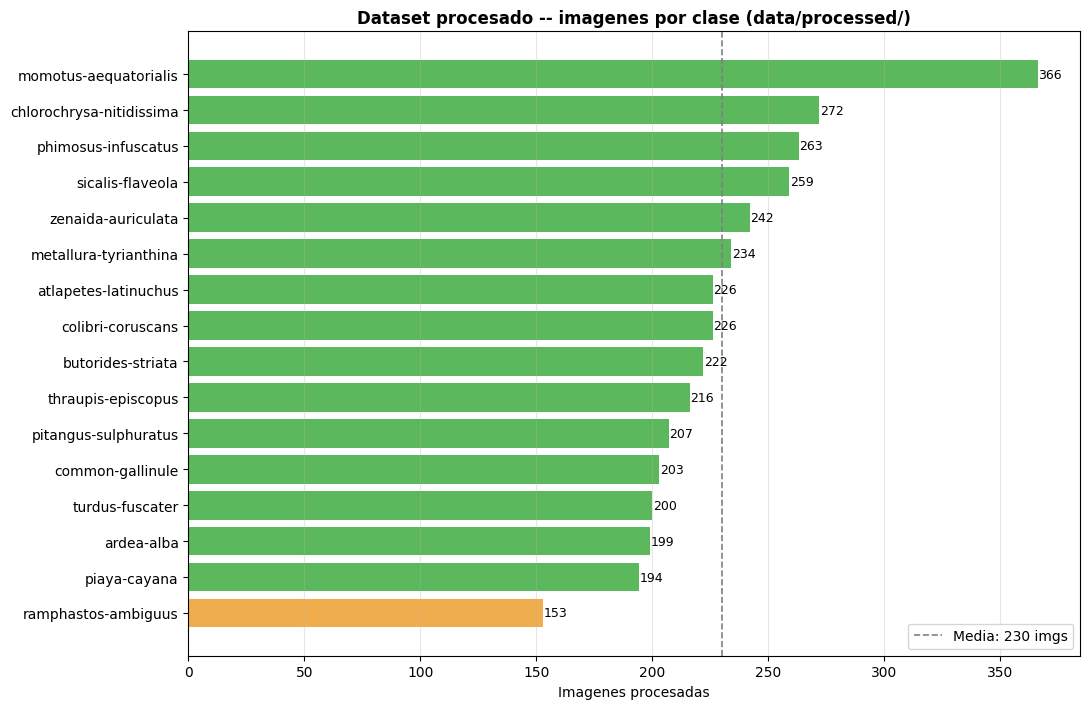

Total imagenes procesadas : 3682
Media por clase           : 230.1

Siguiente paso --> notebooks/03_split.ipynb


In [14]:
# Contar imagenes aceptadas en data/processed/
processed_counts = {}
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

for cls_dir in sorted(PROCESSED_DIR.iterdir()):
    if cls_dir.is_dir():
        processed_counts[cls_dir.name] = sum(
            1 for f in cls_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS
        )

sorted_proc = sorted(processed_counts.items(), key=lambda x: x[1], reverse=True)
names_proc  = [k for k, _ in sorted_proc]
vals_proc   = [v for _, v in sorted_proc]
mean_proc   = np.mean(vals_proc) if vals_proc else 0

bar_colors_p = ["#d9534f" if v < mean_proc * 0.5 else
                "#f0ad4e" if v < mean_proc * 0.8 else
                "#5cb85c" for v in vals_proc]

fig, ax = plt.subplots(figsize=(11, max(5, len(names_proc) * 0.45)))
bars = ax.barh(names_proc[::-1], vals_proc[::-1], color=bar_colors_p[::-1])
ax.axvline(x=mean_proc, color="gray", linestyle="--", linewidth=1.2,
           label=f"Media: {mean_proc:.0f} imgs")
for bar, val in zip(bars, vals_proc[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)
ax.set_xlabel("Imagenes procesadas")
ax.set_title("Dataset procesado -- imagenes por clase (data/processed/)",
             fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "02_processed_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Total imagenes procesadas : {sum(vals_proc)}")
print(f"Media por clase           : {mean_proc:.1f}")
print()
print("Siguiente paso --> notebooks/03_split.ipynb")
